# Portfolio Tracker

Dashboard di monitoraggio del portafoglio ETF.
Esegui le celle in ordine (menu **Run → Run All Cells**) per aggiornare tutto con i prezzi più recenti.

**Come si usa ogni giorno:**
1. Aggiorna `data/transactions.xlsx` con eventuali nuove operazioni
2. Esegui *Run All*
3. Leggi le sezioni: Holdings → Performance → Allocazione → Grafici

La logica di calcolo è in `portfolio.py`. Questo notebook si limita a orchestrare e visualizzare.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import portfolio as pf
import chart_style as cs
import costs as cst

pd.options.display.float_format = lambda x: f'{x:,.2f}'
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
cs.apply_global_style()

TX_FILE = 'data/transactions.xlsx'   # <-- sposta qui il tuo file


## 2. Caricamento operazioni e impostazioni

In [2]:
tx = pf.load_transactions(TX_FILE)
settings = pf.load_settings(TX_FILE)
base_ccy = settings['base_currency']
benchmark = settings['benchmark_ticker']

print(f'Operazioni caricate: {len(tx)}')
print(f'Valuta base: {base_ccy} | Benchmark: {benchmark}')
tx


Operazioni caricate: 5
Valuta base: EUR | Benchmark: VWCE.DE


,date,ticker,isin,name,operation,quantity,price,currency,fees,notes
0,2025-12-10,VWCE.DE,IE00BK5BQT80,Vanguard FTSE All-World (Acc),BUY,10.38,144.54,EUR,1,PAC dicembre
1,2025-12-16,VWCE.DE,IE00BK5BQT80,Vanguard FTSE All-World (Acc),BUY,10.50,142.84,EUR,1,PAC dicembre
2,2026-01-14,VFEA.DE,IE00BK5BR733,Vanguard FTSE Emerging Markets (Acc),BUY,21.26,70.55,EUR,1,PAC gennaio
3,2026-02-06,VWCE.DE,IE00BK5BQT80,Vanguard FTSE All-World (Acc),BUY,10.22,146.84,EUR,1,PAC febbraio
4,2026-03-06,VWCE.DE,IE00BK5BQT80,Vanguard FTSE All-World (Acc),BUY,3.42,146.28,EUR,1,PAC marzo


## 3. Download prezzi (yfinance)

Scarica i prezzi di chiusura giornalieri e li mette in cache locale (`data/prices_cache.parquet`).
Per forzare un refresh completo dei prezzi, esegui prima `pf.refresh_cache()` e poi questa cella.


In [3]:
tickers = sorted(tx['ticker'].unique())
start = tx['date'].min()

#pf.refresh_cache()   # <-- decommenta per riscaricare tutto da zero
prices = pf.fetch_prices(tickers, start=start)

print('Prezzi scaricati per:', list(prices.columns))
print('Periodo:', prices.index.min().date(), '→', prices.index.max().date())
prices.tail()


Prezzi scaricati per: ['VFEA.DE', 'VWCE.DE']
Periodo: 2025-12-10 → 2026-06-11


Ticker,VFEA.DE,VWCE.DE
Date,,
2026-06-05,74.40,162.36
2026-06-08,74.12,161.56
2026-06-09,73.74,159.50
2026-06-10,73.60,159.24
2026-06-11,73.67,159.56


### ⚠️ Diagnostica ticker (eseguire solo se un download fallisce)

Se un ETF risulta vuoto o mancante, il ticker yfinance potrebbe essere diverso.
Per i tuoi Vanguard le alternative tipiche sono:

| ISIN | Xetra (DE) | Borsa Italiana (MI) | Altri |
|---|---|---|---|
| IE00BK5BQT80 (All-World Acc) | `VWCE.DE` | `VWCE.MI` | `VWCE.L`, `VWCE.SW` |
| IE00BK5BR733 (Emerging Acc) | `VFEA.DE` | `VFEA.MI` | `VDEM.L` |

Modifica il ticker nel file Excel (colonna `ticker`) e ri-esegui dalla sezione 2.


In [4]:
# Test rapido di un singolo ticker:
# import yfinance as yf
# yf.Ticker('VWCE.MI').history(period='5d')


## 4. Posizioni correnti (Holdings)

In [5]:
holdings = pf.compute_holdings(tx)
holdings_valued = pf.value_holdings(holdings, prices)

view = holdings_valued[['name','quantity','avg_cost','last_price',
                        'invested','market_value','pnl_eur','pnl_pct','weight']]
view.style.format({
    'quantity':'{:,.4f}', 'avg_cost':'{:,.2f}', 'last_price':'{:,.2f}',
    'invested':'{:,.2f}', 'market_value':'{:,.2f}', 'pnl_eur':'{:,.2f}',
    'pnl_pct':'{:+.2%}', 'weight':'{:.1%}',
}).background_gradient(subset=['pnl_pct'], cmap='RdYlGn')


,name,quantity,avg_cost,last_price,invested,market_value,pnl_eur,pnl_pct,weight
ticker,,,,,,,,,
VFEA.DE,Vanguard FTSE Emerging Markets (Acc),21.2615,70.60,73.67,"1,501.00","1,566.34",65.34,+4.35%,22.1%
VWCE.DE,Vanguard FTSE All-World (Acc),34.5137,144.99,159.56,"5,004.20","5,507.01",502.80,+10.05%,77.9%


## 5. Performance complessiva

In [14]:
vs = pf.portfolio_value_series(tx, prices)
twr = pf.time_weighted_return(vs)
s = pf.summary(holdings_valued, twr)

# === P&L (cash assoluto) ===
print(f"Capitale investito netto : {s['invested']:>12,.2f} {base_ccy}")
print(f"Valore di mercato        : {s['market_value']:>12,.2f} {base_ccy}")
print(f"P&L assoluto             : {s['pnl_eur']:>+12,.2f} {base_ccy}")
print(f"P&L semplice             : {s['pnl_pct']:>+12.2%}")
print()

# === Performance percentuali: TWR e MWR ===
mwr_res = pf.money_weighted_return(tx, s['market_value'])
comp = pf.compare_twr_mwr(twr, mwr_res)

print("─" * 60)
print("RENDIMENTO PERCENTUALE (due metodologie complementari)")
print("─" * 60)
if comp['twr_annualized'] is not None:
    print(f"TWR cumulato             : {comp['twr_cumulative']:>+12.2%}")
    print(f"TWR annualizzato         : {comp['twr_annualized']:>+12.2%}   "
          f"(performance pura degli strumenti)")
if comp['mwr_annualized'] is not None:
    print(f"MWR cumulato             : {comp['mwr_cumulative']:>+12.2%}")
    print(f"MWR annualizzato         : {comp['mwr_annualized']:>+12.2%}   "
          f"(rendimento effettivo del tuo capitale)")
    print(f"Spread (MWR − TWR)       : {comp['spread_annualized']:>+12.2%} pp")
print()
print("💡", comp['interpretation'])


Capitale investito netto :     6,505.20 EUR
Valore di mercato        :     7,073.34 EUR
P&L assoluto             :      +568.14 EUR
P&L semplice             :       +8.73%

────────────────────────────────────────────────────────────
RENDIMENTO PERCENTUALE (due metodologie complementari)
────────────────────────────────────────────────────────────
TWR cumulato             :       +9.38%
TWR annualizzato         :      +46.33%   (performance pura degli strumenti)
MWR cumulato             :      +13.44%
MWR annualizzato         :      +70.80%   (rendimento effettivo del tuo capitale)
Spread (MWR − TWR)       :      +24.47% pp

💡 Il timing dei tuoi versamenti è stato vantaggioso: il rendimento effettivo (MWR +70.80%) supera quello degli strumenti (TWR +46.33%) di +24.47 pp annualizzati. Hai mediamente investito di più nei periodi di mercato basso. ⚠️ Il portafoglio ha solo 86 giorni di storia: l'annualizzazione di rendimenti su periodi brevi tende a sovrastimare la performance attesa di l

Il **P&L semplice** confronta valore attuale con capitale investito.
Il **TWR** (time-weighted return) isola la performance degli strumenti dall'effetto del *timing*
dei tuoi versamenti — è la misura corretta per valutare l'andamento del portafoglio
indipendentemente da quando hai messo i soldi (standard GIPS).

## 6. Allocazione: effettiva vs target

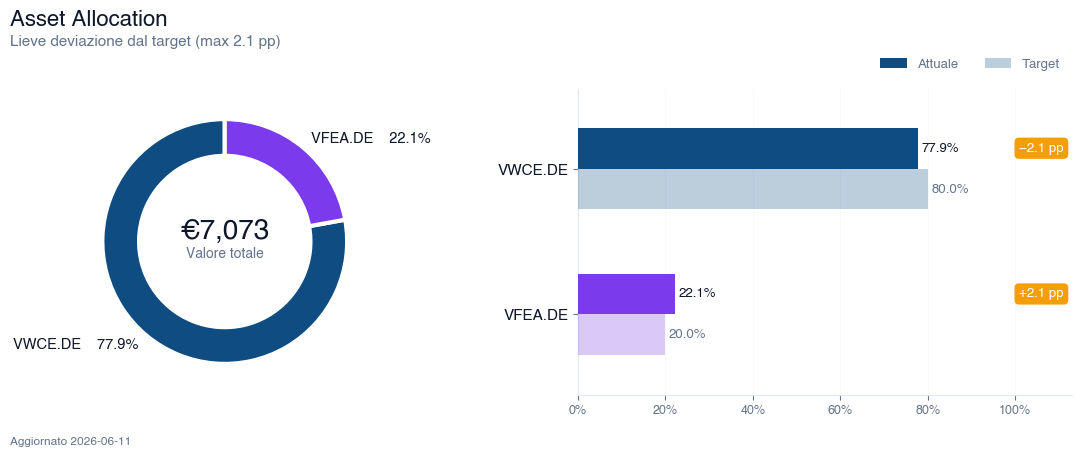

,name,weight,target,deviation
ticker,,,,
VFEA.DE,Vanguard FTSE Emerging Markets (Acc),22.1%,20.0%,+2.1%
VWCE.DE,Vanguard FTSE All-World (Acc),77.9%,80.0%,-2.1%


In [7]:
target = settings['target_allocation']
alloc = holdings_valued[['name','weight']].copy()
alloc['target'] = alloc.index.map(target).fillna(0.0)
alloc['deviation'] = alloc['weight'] - alloc['target']

total_value = holdings_valued['market_value'].sum()

# Ordina per valore decrescente: la posizione principale prende il colore primario
sorted_tickers = list(holdings_valued['market_value'].sort_values(ascending=False).index)
sorted_sizes   = holdings_valued['market_value'].loc[sorted_tickers]
color_map = {t: cs.PALETTE[i % len(cs.PALETTE)] for i, t in enumerate(sorted_tickers)}

# Soglie color-coding scostamento
def dev_color(d):
    a = abs(d)
    if a < 0.01:  return cs.COLORS['gain']
    if a < 0.03:  return cs.COLORS['amber']
    return cs.COLORS['loss']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5),
                         gridspec_kw={'width_ratios':[1.0, 1.15]})

# === PANNELLO SINISTRO: DONUT ===
ax = axes[0]
colors = [color_map[t] for t in sorted_tickers]
labels = [f"{t}    {sorted_sizes.loc[t]/total_value*100:.1f}%"
          for t in sorted_tickers]
ax.pie(
    sorted_sizes, labels=labels, startangle=90, colors=colors,
    wedgeprops=dict(width=0.30, edgecolor='white', linewidth=3),
    textprops=dict(color=cs.COLORS['fg'], fontsize=10.5),
    labeldistance=1.10,
)
ax.text(0, 0.08, f'€{total_value:,.0f}', ha='center', va='center',
        fontsize=20, fontweight='bold', color=cs.COLORS['fg'])
ax.text(0, -0.10, 'Valore totale', ha='center', va='center',
        fontsize=10, color=cs.COLORS['muted'])

# === PANNELLO DESTRO: BARRE ORIZZONTALI ===
ax = axes[1]
cs.style_axis(ax, euro=False, date_axis=False)
ax.grid(True, axis='x', color=cs.COLORS['grid'], linewidth=0.6)
ax.grid(False, axis='y')

n = len(sorted_tickers); y = np.arange(n); h = 0.28

for i, t in enumerate(sorted_tickers):
    c = color_map[t]
    w_now = alloc.loc[t, 'weight']
    w_tgt = alloc.loc[t, 'target']
    d = alloc.loc[t, 'deviation']

    ax.barh(y[i] - h/2, w_now, h, color=c,
            label='Attuale' if i == 0 else None, zorder=3)
    ax.barh(y[i] + h/2, w_tgt, h, color=c, alpha=0.28,
            label='Target' if i == 0 else None, zorder=3)

    ax.text(w_now + 0.008, y[i] - h/2, f'{w_now*100:.1f}%',
            va='center', ha='left', fontsize=9.5, fontweight='bold',
            color=cs.COLORS['fg'])
    ax.text(w_tgt + 0.008, y[i] + h/2, f'{w_tgt*100:.1f}%',
            va='center', ha='left', fontsize=9.5, color=cs.COLORS['muted'])

    # Chip scostamento in colonna fissa a destra
    sign = '+' if d >= 0 else '−'
    ax.text(1.06, y[i] - h/2, f'{sign}{abs(d)*100:.1f} pp',
            va='center', ha='center', fontsize=9.5, fontweight='bold',
            color='white',
            bbox=dict(facecolor=dev_color(d), edgecolor='none',
                      boxstyle='round,pad=0.35'))

ax.set_yticks(y)
ax.set_yticklabels(sorted_tickers, fontsize=11, color=cs.COLORS['fg'],
                   fontweight='bold')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_xlim(0, 1.13)
ax.set_ylim(n - 0.45, -0.55)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Legenda orizzontale in alto a destra del pannello
leg = ax.legend(loc='lower right', frameon=False, fontsize=9.5,
                ncol=2, bbox_to_anchor=(1.0, 1.02))
for t in leg.get_texts(): t.set_color(cs.COLORS['muted'])

# === Titolo + sottotitolo + footer ===
max_dev = alloc['deviation'].abs().max() * 100
if max_dev < 1.0:
    subtitle = "Portafoglio in linea col target (deviazione < 1 pp)"
elif max_dev < 3.0:
    subtitle = f"Lieve deviazione dal target (max {max_dev:.1f} pp)"
else:
    subtitle = f"Ribilanciamento consigliato (deviazione max {max_dev:.1f} pp)"

cs.add_title(
    fig,
    title='Asset Allocation',
    subtitle=subtitle,
    source=f'Aggiornato {prices.index[-1].date()}',
)
plt.subplots_adjust(top=0.81, bottom=0.13, wspace=0.30)
plt.show()

# Tabella riassuntiva
alloc.style.format({
    'weight':'{:.1%}', 'target':'{:.1%}', 'deviation':'{:+.1%}',
})

## 7. Andamento del valore nel tempo

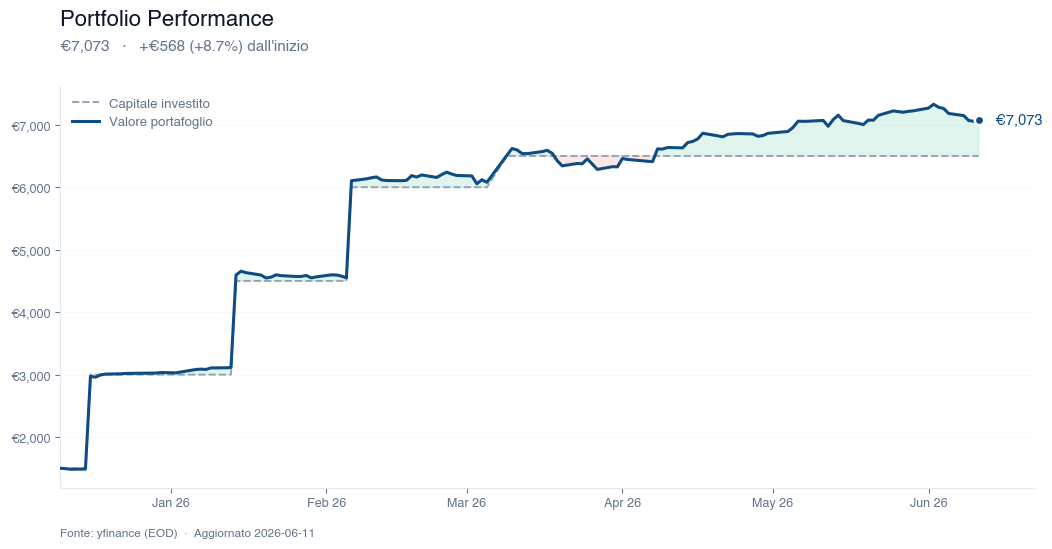

In [8]:
invested_cum = vs['flow'].cumsum()
last_x  = vs.index[-1]
last_v  = vs['value'].iloc[-1]
last_i  = invested_cum.iloc[-1]
pnl     = last_v - last_i
pnl_pct = pnl / last_i if last_i else 0

fig, ax = plt.subplots(figsize=(11, 5.5))
cs.style_axis(ax)

# area gain/loss
ax.fill_between(vs.index, vs['value'], invested_cum,
                where=(vs['value'] >= invested_cum),
                color=cs.COLORS['gain'], alpha=0.13, interpolate=True, zorder=1)
ax.fill_between(vs.index, vs['value'], invested_cum,
                where=(vs['value'] < invested_cum),
                color=cs.COLORS['loss'], alpha=0.13, interpolate=True, zorder=1)

# linee
ax.plot(vs.index, invested_cum, color=cs.COLORS['invested'], linewidth=1.4,
        linestyle='--', label='Capitale investito', zorder=2)
ax.plot(vs.index, vs['value'], color=cs.COLORS['value'], linewidth=2.2,
        label='Valore portafoglio', zorder=3)

# marker e label sul valore corrente
ax.scatter([last_x], [last_v], color=cs.COLORS['value'], s=45, zorder=4,
           edgecolor='white', linewidth=1.8)
ax.annotate(f'  €{last_v:,.0f}', xy=(last_x, last_v),
            xytext=(6, 0), textcoords='offset points',
            va='center', ha='left', fontsize=10.5, fontweight='bold',
            color=cs.COLORS['value'])

# margine a destra per l'annotazione
span = vs.index[-1] - vs.index[0]
ax.set_xlim(vs.index[0], vs.index[-1] + span * 0.06)

cs.style_legend(ax)
sign = '+' if pnl >= 0 else '−'
cs.add_title(
    fig,
    title='Portfolio Performance',
    subtitle=f'€{last_v:,.0f}   ·   {sign}€{abs(pnl):,.0f} ({pnl_pct:+.1%}) dall\'inizio',
    source=f'Fonte: yfinance (EOD)  ·  Aggiornato {vs.index[-1].date()}',
)
plt.show()

## 8. Performance TWR vs Benchmark

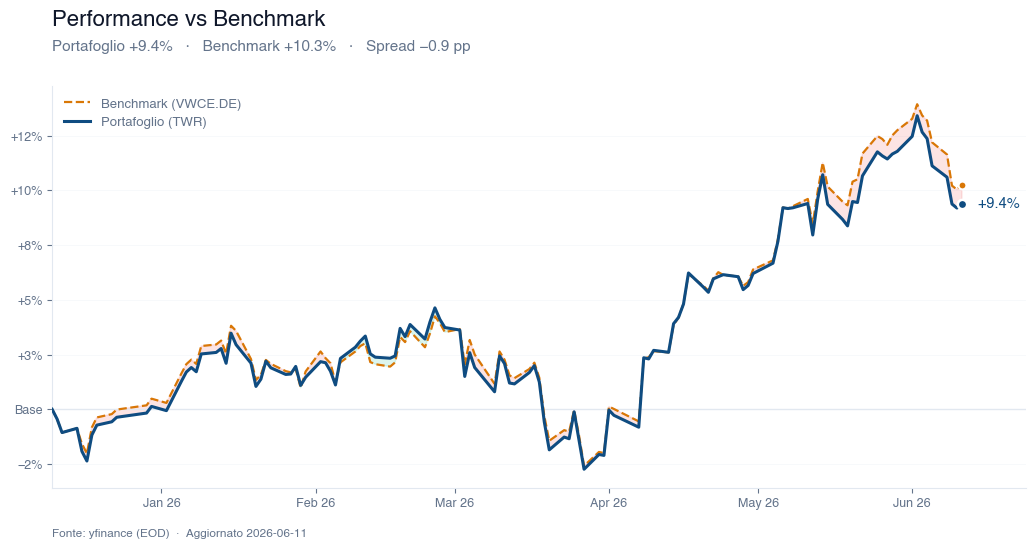

In [9]:
bench = pf.fetch_prices([benchmark], start=vs.index.min())[benchmark]
bench = bench.reindex(vs.index).ffill()
bench_norm = bench / bench.iloc[0]

# Allinea le due serie sullo stesso indice
common_idx = twr.index.intersection(bench_norm.index)
twr_a   = twr.reindex(common_idx)
bench_a = bench_norm.reindex(common_idx)

last_p = twr_a.iloc[-1]
last_b = bench_a.iloc[-1]
ret_p  = last_p - 1
ret_b  = last_b - 1
spread = ret_p - ret_b

fig, ax = plt.subplots(figsize=(11, 5.5))
cs.style_axis(ax, euro=False)

# Asse Y come variazione percentuale dalla base
def pct_fmt(v, _):
    delta = v - 1.0
    if abs(delta) < 0.0005:
        return 'Base'
    sign = '+' if delta >= 0 else '−'
    return f'{sign}{abs(delta)*100:.0f}%'
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))

# Area outperformance / underperformance vs benchmark
ax.fill_between(common_idx, twr_a, bench_a,
                where=(twr_a >= bench_a),
                color=cs.COLORS['gain'], alpha=0.14, interpolate=True, zorder=1)
ax.fill_between(common_idx, twr_a, bench_a,
                where=(twr_a < bench_a),
                color=cs.COLORS['loss'], alpha=0.14, interpolate=True, zorder=1)

# Baseline 0%
ax.axhline(1.0, color=cs.COLORS['grid'], linewidth=1.0, zorder=1)

# Linee
ax.plot(bench_a.index, bench_a, color=cs.COLORS['benchmark'], linewidth=1.6,
        linestyle='--', label=f'Benchmark ({benchmark})', zorder=2)
ax.plot(twr_a.index, twr_a, color=cs.COLORS['value'], linewidth=2.2,
        label='Portafoglio (TWR)', zorder=3)

# Marker e label finale
ax.scatter([common_idx[-1]], [last_p], color=cs.COLORS['value'], s=45,
           zorder=5, edgecolor='white', linewidth=1.8)
ax.scatter([common_idx[-1]], [last_b], color=cs.COLORS['benchmark'], s=32,
           zorder=5, edgecolor='white', linewidth=1.5)
ax.annotate(f'  {ret_p*100:+.1f}%', xy=(common_idx[-1], last_p),
            xytext=(6, 0), textcoords='offset points',
            va='center', ha='left', fontsize=10.5, fontweight='bold',
            color=cs.COLORS['value'])

# Margine destro per le annotazioni
span = common_idx[-1] - common_idx[0]
ax.set_xlim(common_idx[0], common_idx[-1] + span * 0.07)

cs.style_legend(ax)

sign_sp = '+' if spread >= 0 else '−'
cs.add_title(
    fig,
    title='Performance vs Benchmark',
    subtitle=(f'Portafoglio {ret_p*100:+.1f}%   ·   '
              f'Benchmark {ret_b*100:+.1f}%   ·   '
              f'Spread {sign_sp}{abs(spread)*100:.1f} pp'),
    source=f'Fonte: yfinance (EOD)  ·  Aggiornato {common_idx[-1].date()}',
)
plt.show()

---
### Prossimi passi possibili
- Metriche di rischio: volatilità annualizzata, Sharpe, max drawdown
- Gestione dividendi e tassazione italiana (26% capital gain, bollo 0,2%)
- Suggerimenti automatici di ribilanciamento (quanto comprare per tornare al target)
- Import semi-automatico dal PDF tax statement di Trade Republic

Buon monitoraggio! 📈


In [10]:
import add_costs_sheets
add_costs_sheets.add_costs_sheets(TX_FILE)

Nessuna modifica: i fogli "ter" e "bollo_charges" esistono già
  Fogli ora presenti: ['transactions', 'settings', 'ter', 'bollo_charges']


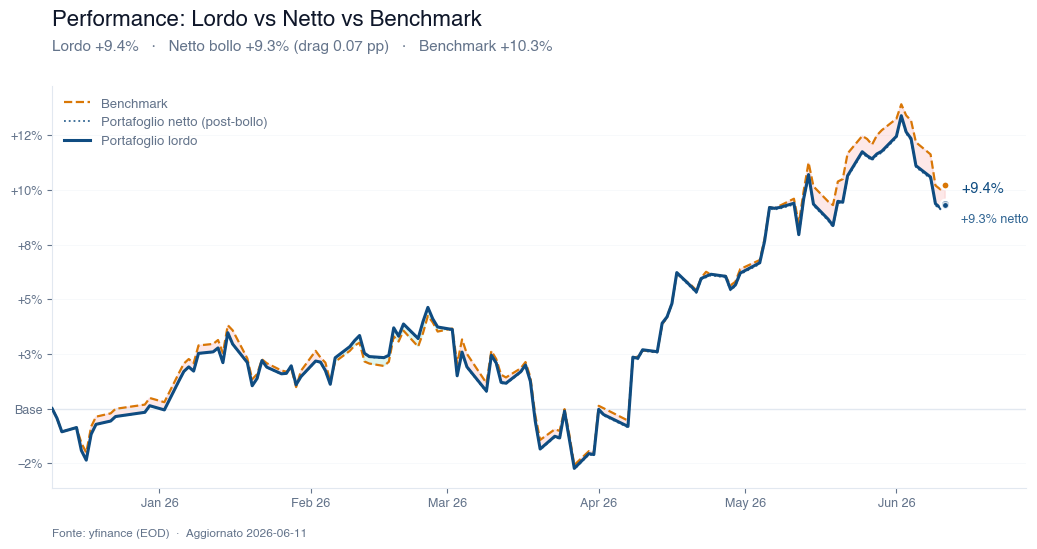

In [11]:
# Carica costi e calcola TWR netto post-bollo
costs_cfg = cst.load_costs(TX_FILE)
twr_net = pf.time_weighted_return(cst.value_series_net_of_bollo(vs))

bench = pf.fetch_prices([benchmark], start=vs.index.min())[benchmark]
bench = bench.reindex(vs.index).ffill()
bench_norm = bench / bench.iloc[0]

# Allinea
common_idx = twr.index.intersection(bench_norm.index)
twr_a       = twr.reindex(common_idx)
twr_net_a   = twr_net.reindex(common_idx)
bench_a     = bench_norm.reindex(common_idx)

last_p, last_pn, last_b = twr_a.iloc[-1], twr_net_a.iloc[-1], bench_a.iloc[-1]
ret_p   = (last_p - 1) * 100
ret_pn  = (last_pn - 1) * 100
ret_b   = (last_b - 1) * 100
drag_pp = ret_p - ret_pn

fig, ax = plt.subplots(figsize=(11, 5.5))
cs.style_axis(ax, euro=False)

def pct_fmt(v, _):
    delta = v - 1.0
    if abs(delta) < 0.0005: return 'Base'
    sign = '+' if delta >= 0 else '−'
    return f'{sign}{abs(delta)*100:.0f}%'
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))

# Fill outperformance vs benchmark (sul lordo)
ax.fill_between(common_idx, twr_a, bench_a, where=(twr_a >= bench_a),
                color=cs.COLORS['gain'], alpha=0.12, interpolate=True, zorder=1)
ax.fill_between(common_idx, twr_a, bench_a, where=(twr_a < bench_a),
                color=cs.COLORS['loss'], alpha=0.12, interpolate=True, zorder=1)
ax.axhline(1.0, color=cs.COLORS['grid'], linewidth=1.0, zorder=1)

# Linee
ax.plot(bench_a.index, bench_a, color=cs.COLORS['benchmark'], linewidth=1.6,
        linestyle='--', label='Benchmark', zorder=2)
ax.plot(twr_net_a.index, twr_net_a, color=cs.COLORS['value'], linewidth=1.3,
        linestyle=':', label='Portafoglio netto (post-bollo)', alpha=0.85, zorder=3)
ax.plot(twr_a.index, twr_a, color=cs.COLORS['value'], linewidth=2.2,
        label='Portafoglio lordo', zorder=4)

# Marker e annotazioni
ax.scatter([common_idx[-1]], [last_p], color=cs.COLORS['value'], s=45, zorder=6,
           edgecolor='white', linewidth=1.8)
ax.scatter([common_idx[-1]], [last_pn], color=cs.COLORS['value'], s=22, zorder=6,
           edgecolor='white', linewidth=1.2, alpha=0.8)
ax.scatter([common_idx[-1]], [last_b], color=cs.COLORS['benchmark'], s=32, zorder=6,
           edgecolor='white', linewidth=1.5)
ax.annotate(f'  {ret_p:+.1f}%', xy=(common_idx[-1], last_p),
            xytext=(6, 6), textcoords='offset points', va='bottom', ha='left',
            fontsize=10.5, fontweight='bold', color=cs.COLORS['value'])
ax.annotate(f'  {ret_pn:+.1f}% netto', xy=(common_idx[-1], last_pn),
            xytext=(6, -6), textcoords='offset points', va='top', ha='left',
            fontsize=9, color=cs.COLORS['value'], alpha=0.85)

span = common_idx[-1] - common_idx[0]
ax.set_xlim(common_idx[0], common_idx[-1] + span * 0.09)
cs.style_legend(ax)

cs.add_title(
    fig,
    title='Performance: Lordo vs Netto vs Benchmark',
    subtitle=(f'Lordo {ret_p:+.1f}%   ·   '
              f'Netto bollo {ret_pn:+.1f}% (drag {drag_pp:.2f} pp)   ·   '
              f'Benchmark {ret_b:+.1f}%'),
    source=f'Fonte: yfinance (EOD)  ·  Aggiornato {common_idx[-1].date()}',
)
plt.show()

In [12]:
## 9. Costi e fiscalità
summary = cst.cost_summary(tx, holdings_valued, vs, costs_cfg)

# === Tabella riepilogo ===
import pandas as pd
rows = [
    ('P&L lordo',               f"€{summary['pnl_lordo']:+,.2f}",
     f"{summary['pnl_lordo_pct']:+.2%}"),
    ('  − Commissioni TR',      f"€{summary['fees_total']:,.2f}", ''),
    ('  − Bollo (modello)',     f"€{summary['bollo_model']:,.2f}", ''),
    ('     Bollo (reale TR)',   f"€{summary['bollo_real']:,.2f}",  '(informativo)'),
    ('  − Imposta plus 26%',    f"€{summary['cap_gain_tax']:,.2f}",
     '(solo se vendi oggi)'),
    ('P&L netto netto',         f"€{summary['pnl_net_net']:+,.2f}",
     f"{summary['pnl_net_net_pct']:+.2%}"),
    ('TER pesato annuo',        f"{summary['ter_weighted']*100:.3f}%",
     f"~€{summary['ter_annual_eur']:,.2f}/anno, già nel NAV"),
]
df_summary = pd.DataFrame(rows, columns=['Voce', 'Importo', 'Note'])
df_summary.style.hide(axis='index')

Voce,Importo,Note
P&L lordo,€+568.14,+8.73%
− Commissioni TR,€5.00,
− Bollo (modello),€3.87,
Bollo (reale TR),€3.20,(informativo)
− Imposta plus 26%,€147.72,(solo se vendi oggi)
P&L netto netto,€+411.55,+6.33%
TER pesato annuo,0.190%,"~€13.44/anno, già nel NAV"


In [13]:
# meglio partire dal rendimento P&L o da quello TWR?